In [2]:
%load_ext autoreload
%autoreload 2
import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import os
REDIS = os.environ.get('REDIS_SERVICE', "redis") #default=redis
REDIS_PORT = os.environ.get('REDIS_PORT', 6379) #default=6379
redis_max_connections = os.environ.get('REDIS_MAX_CONNECTIONS', 1024) #default=1024
redis_cache_size = os.environ.get('REDIS_CACHE_SIZE', 500)  #default=200
redis_cache_expire_time = os.environ.get('REDIS_CACHE_EXPIRE_TIME', 7*24*60*60)  #default=7*24*60*60
config_input_size = os.environ.get('IMAGE_INPUT_SIZE', 1024)  #default=1024
use_gpu = os.environ.get("SERVER_RUNTIME", "runc") == "nvidia"
user_focus_preload_scope = os.environ.get("PRELOAD_SCOPE", 5) #default scope=5
import time
import pickle
from rds import RedisAccess
from typing import List, Optional


In [3]:
from PIL import Image

import os
# os.chdir('../')

sam2_checkpoint = "/home/a70495/sam2/checkpoints/sam2.1_hiera_base_plus.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_b+.yaml"
from sam2.build_sam import build_sam2_video_predictor

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device='cpu')


rds = RedisAccess(0)

video_dir = "./videos/bedroom"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))
# inference_state = predictor.init_state(video_path=video_dir)
img_list = [{"md5": os.path.splitext(p)[0], "data":Image.open(os.path.join(video_dir,p))} for idx,p in enumerate(frame_names)]
model_id = "sam2.1_hiera_base_plus"


configs/sam2.1/sam2.1_hiera_b+.yaml


In [4]:
def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))

In [5]:
video_dir_for_init = 'videos/bedroom01'
inference_state = predictor.init_state(video_path=video_dir_for_init)
img_list = [{"md5": os.path.splitext(p)[0]} for idx,p in enumerate(frame_names)]
inference_state['rds'] = rds
inference_state['img_list'] = img_list
inference_state['model_id'] = model_id
inference_state["num_frames"] = 200

frame loading (JPEG): 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 18.98it/s]


In [6]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1
mask = np.load('mask.npy')

_,out_obj_ids, out_mask_logits = predictor.add_new_mask(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    mask=mask
)

/home/a70495/sam2_dev/sam2/sam2_video_predictor.py:726: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image).to(device)
/home/a70495/sam2_dev/sam2/sam2_video_predictor.py:808: UserWarning: cannot import name '_C' from 'sam2' (/home/a70495/sam2_dev/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(


propagate in video: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 21/21 [00:29<00:00,  1.41s/it]


time: 30.01s


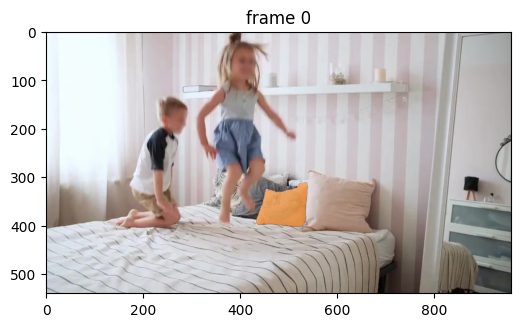

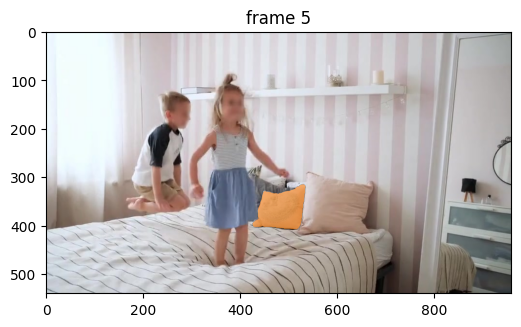

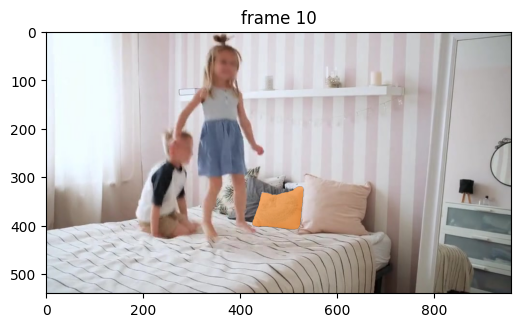

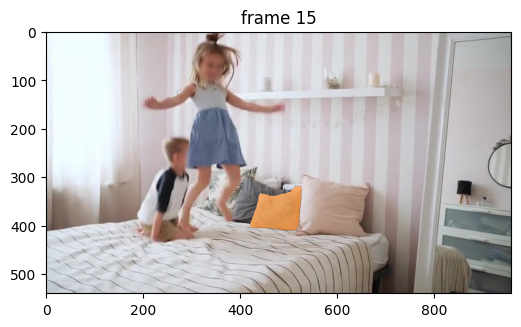

In [7]:
import time
start = time.time()
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
start_frame_idx = 0
max_frame_num_to_track = 20
track_obj_list = [1]
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state,start_frame_idx=start_frame_idx,
                             max_frame_num_to_track=max_frame_num_to_track,track_obj_list=track_obj_list):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }
    # break
print(f'time: {time.time() - start:.2f}s')
# # render the segmentation results every few frames
vis_frame_stride = 5
plt.close("all")
for out_frame_idx in range(start_frame_idx, start_frame_idx + max_frame_num_to_track, vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)